<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB30 · Domar el ruido: ventaja, normalización, crítico y descuento

**Parte 4 · Aprendizaje por refuerzo de verdad — Lección 3**

> En el **NB29** el palo de escoba aprendió **solo** con REINFORCE. Y viste que una sola línea (restar la media, la **línea base**) separaba un
> algoritmo inútil de uno que funciona. Hoy entenderemos **por qué**, lo **mediremos**, y lo llevaremos más lejos.

El enemigo de todo el aprendizaje por refuerzo tiene un nombre: el **ruido** (los matemáticos lo llaman **varianza**). Cada vez que estimamos "hacia dónde
mejorar" a partir de unos pocos episodios al azar, la estimación sale distinta, y a veces apunta en la dirección equivocada. Cuanto más ruido, más episodios
hacen falta, y más inestable es el aprendizaje. Con un humanoide, eso es la diferencia entre entrenar en horas o no conseguirlo nunca.

Hoy veremos las cuatro armas contra el ruido que usan **todos** los algoritmos modernos:

1. **Medir** el ruido (para saber si una idea ayuda de verdad).
2. **Normalizar** las ventajas.
3. El **crítico**: una pieza que aprende **cuánto vale cada situación**, para comparar cada acción con lo que era "normal" **justo en ese momento**.
4. Elegir bien el **descuento**.

Con ellas daremos el paso hacia la arquitectura **actor-crítico**, la base de PPO.


## 1 · El laboratorio

Traemos las piezas del NB29, tal cual: jugar episodios en paralelo apuntándolo todo, calcular los retornos desde cada paso y la dirección de mejora. (Si vienes del NB29 te
sonarán línea a línea; si no, allí están explicadas.)


In [1]:
import numpy as np
import matplotlib.pyplot as plt

def jugar(pesos, sigma, n_episodios, generador, pasos_maximos=500):
    inclinacion = np.full(n_episodios, 2.0)
    velocidad = np.zeros(n_episodios)
    vivos = np.ones(n_episodios, dtype=bool)
    observaciones = np.zeros((pasos_maximos, n_episodios, 2))
    acciones = np.zeros((pasos_maximos, n_episodios))
    medias = np.zeros((pasos_maximos, n_episodios))
    recompensas = np.zeros((pasos_maximos, n_episodios))
    estaba_vivo = np.zeros((pasos_maximos, n_episodios), dtype=bool)
    for t in range(pasos_maximos):
        observacion = np.stack([inclinacion, velocidad], axis=1)
        media = observacion @ pesos
        accion = media + sigma * generador.standard_normal(n_episodios)
        observaciones[t], acciones[t], medias[t], estaba_vivo[t] = observacion, accion, media, vivos
        empuje = np.clip(accion, -40, 40)
        aceleracion = 10 * inclinacion + empuje + generador.uniform(-30, 30, n_episodios)
        velocidad = velocidad + aceleracion * 0.02
        inclinacion = inclinacion + velocidad * 0.02
        vivos = vivos & (np.abs(inclinacion) <= 30)
        recompensas[t] = np.where(vivos, 1 - (inclinacion / 30) ** 2, 0.0)
    return observaciones, acciones, medias, recompensas, estaba_vivo

def retornos_desde_cada_paso(recompensas, gamma=0.99):
    G = np.zeros_like(recompensas)
    acumulado = np.zeros(recompensas.shape[1])
    for t in reversed(range(recompensas.shape[0])):
        acumulado = recompensas[t] + gamma * acumulado
        G[t] = acumulado
    return G

def direccion_de_mejora(observaciones, acciones, medias, ventajas, estaba_vivo, sigma):
    hacia_mas_probable = ((acciones - medias) / sigma ** 2)[..., None] * observaciones
    votos = (ventajas * estaba_vivo)[..., None] * hacia_mas_probable
    return votos.sum(axis=0).mean(axis=0)

print("Laboratorio listo")

Laboratorio listo


## 2 · Arma 1: medir el ruido

En el NB29 dijimos que REINFORCE puro "tenía mucho ruido". Un ingeniero no se queda en "mucho": **lo mide** (NB07). ¿Cómo se mide el ruido de una estimación? Como en el NB28: repitiéndola
**muchas veces** en las mismas condiciones y mirando **cuánto se dispersan** los resultados (su desviación típica).

Fijamos unos pesos cualesquiera, por ejemplo (−5, −3) (una política mediocre, a mitad de aprender), y estimamos la dirección de mejora **40 veces**, cada una con un lote nuevo de 50
episodios. Lo hacemos sin línea base y con la línea base del NB29 (la media del retorno en cada paso):


In [2]:
pesos_fijos = np.array([-5.0, -3.0])

def estimar_muchas_veces(usar_linea_base, repeticiones=40):
    generador = np.random.default_rng(7)
    estimaciones = []
    for r in range(repeticiones):
        obs, acc, med, rec, vivo = jugar(pesos_fijos, 5.0, 50, generador)
        G = retornos_desde_cada_paso(rec)
        ventajas = G - G.mean(axis=1, keepdims=True) if usar_linea_base else G
        estimaciones.append(direccion_de_mejora(obs, acc, med, ventajas, vivo, 5.0))
    return np.array(estimaciones)                    # (40, 2): 40 flechas de dirección

for nombre, usar in [("sin línea base", False), ("con línea base", True)]:
    e = estimar_muchas_veces(usar)
    print(f"{nombre}: media de las 40 estimaciones {e.mean(axis=0).round(1)} | dispersión {e.std(axis=0).round(1)}")

sin línea base: media de las 40 estimaciones [8.2 9.2] | dispersión [34.  44.3]


con línea base: media de las 40 estimaciones [-3.5 -3.8] | dispersión [ 9.5 20.4]


Mira las dos columnas de números:

- **Dispersión**: sin línea base, las 40 estimaciones bailan con una desviación típica de unos **34 y 44**; con línea base, de unos **10 y 20**. **Entre dos y cuatro veces menos
  ruido** con una sola línea de código. Ahora "mucho ruido" es un número.
- **Media**: con línea base, la media de las 40 estimaciones apunta claramente hacia valores **negativos** (hacia empujar más en contra de la caída: hacia la política buena). Sin línea
  base, la media sale... ¡**positiva**! Con tanto ruido, ni siquiera 40 lotes (2.000 episodios) bastan para estar seguros de la **dirección** (fíjate: la teoría dice que la dirección
  promedio es la misma con y sin línea base; lo que pasa es que, sin ella, el error típico, NB28, es tan grande que 40 estimaciones no alcanzan para verla).

Esto explica de golpe el fracaso del NB29: con 50 episodios por paso, REINFORCE puro avanzaba **a ciegas**.


## 3 · Arma 2: normalizar las ventajas

La segunda arma es muy sencilla, y la usa casi todo el mundo. Las ventajas (G menos la línea base) pueden ser números de cualquier tamaño: al principio del entrenamiento, cuando el palo
se cae enseguida, son pequeñas; más adelante, cuando aguanta cientos de pasos, enormes. Eso hace que el **tamaño de los pasos** de aprendizaje cambie muchísimo a lo largo del entrenamiento
(pasos minúsculos al principio, gigantescos después), y que la tasa de aprendizaje buena al principio sea malísima al final.

La solución: en cada lote, **normalizar** las ventajas como normalizamos las observaciones en el NB27: restarles su media y dividirlas entre su desviación típica. Así, en **cada** lote, las
ventajas tienen media 0 y desviación 1: la mitad de las acciones se refuerzan, la otra mitad se debilitan, y el tamaño de los pasos lo decide **solo** la tasa de aprendizaje.

```
   ventajas normalizadas = (ventajas − su media) / su desviación típica
```

Como cambia la escala de los pasos, la tasa de aprendizaje buena también cambia (ahora usaremos 0,3). Lo probaremos en el apartado 5, junto al crítico.


## 4 · Arma 3: el crítico

La línea base del NB29 compara cada acción con **la media de todos los episodios en ese mismo paso**. Pero piensa en lo que significa: en el paso 30, un episodio puede tener el palo casi
derecho (y por delante, muchos puntos) y otro a punto de caer (y por delante, casi nada). ¿Es justo compararlos con la misma "media"? No: lo justo sería comparar cada acción con lo que era
"normal" **en su situación concreta**.

Para eso hace falta saber **cuánto vale cada situación**: "con el palo así de inclinado, girando a esta velocidad, en este momento del episodio, ¿cuántos puntos suelo sacar de aquí en adelante?".
A ese número se le llama el **valor** de la situación, y a la función que lo calcula, la **función de valor**, que se escribe **V(s)** (la *s* es de *situación*, o *state*, "estado").

```
   V(situación) = el retorno que se espera sacar desde esa situación (NB28: valor esperado)
```

¿Y cómo se conoce V? ¡**Aprendiéndola**! Tenemos muchísimos ejemplos: cada paso de cada episodio es una situación, y sabemos el retorno que vino después (su G). Aprender V es **aprendizaje
supervisado** (NB18): ajustar una "neurona" para que, a partir de la situación, **prediga** G. A esta segunda neurona se le llama el **crítico** (porque **juzga** cada situación), y a la
política, el **actor** (porque **actúa**). Juntos forman la arquitectura **actor-crítico**:

```
   ACTOR  (la política):   "en esta situación, hago esto"        → decide las acciones
   CRÍTICO (la función V):  "esta situación suele valer tanto"    → sirve de línea base para juzgar al actor

   ventaja = G (lo que pasó de verdad) − V(situación) (lo que solía pasar)
```

Una acción con ventaja positiva hizo las cosas **mejor de lo que solía salir en esa misma situación**: un juicio mucho más justo que compararla con la media de todo el lote.


### ¿Qué necesita mirar el crítico?

El crítico tiene que predecir el valor a partir de la situación. ¿Qué datos le damos? Pensemos como un ingeniero (NB03: elegir bien la observación es parte del trabajo):

- **La inclinación, pero al cuadrado.** Lo que importa es **cuánto** está inclinado, no hacia qué lado: estar inclinado 10 grados a la derecha es igual de malo que 10 a la izquierda. Una
  neurona lineal con la inclinación tal cual no puede captar eso (daría valores opuestos a −10 y a +10); con la inclinación **al cuadrado**, sí (las dos dan 100). Lo mismo con la **velocidad
  al cuadrado**.
- **El producto inclinación × velocidad**: distingue "inclinado y cayéndose más" (los dos con el mismo signo: producto positivo, malo) de "inclinado pero volviendo" (signos opuestos:
  negativo, bueno). ¡El problema de la foto del NB03, otra vez!
- **El momento del episodio** (el paso dividido entre 500): como el episodio se corta a los 500 pasos, cerca del final quedan menos recompensas por delante, aunque el palo esté perfecto.
- Y un **1** fijo (para que el crítico tenga un sesgo, NB13).

A estos datos fabricados para una neurona se les llama **rasgos** (*features*). Elegirlos bien es un arte (y las redes neuronales del NB19 lo hacen solas: aprenden sus propios rasgos en las
capas ocultas).


In [3]:
def rasgos(observaciones):
    inclinacion = observaciones[..., 0]
    velocidad = observaciones[..., 1]
    pasos, episodios = inclinacion.shape
    momento = np.repeat(np.arange(pasos)[:, None], episodios, axis=1) / pasos    # el paso de cada dato, de 0 a 1
    return np.stack([np.ones_like(inclinacion), inclinacion ** 2, velocidad ** 2,
                     inclinacion * velocidad, momento], axis=-1)                 # (pasos, episodios, 5)

print("Forma de los rasgos:", rasgos(np.zeros((500, 50, 2))).shape)

Forma de los rasgos: (500, 50, 5)


(`np.repeat` repite un array: aquí, el número de paso, una vez por episodio.)

### Ajustar el crítico de un golpe: mínimos cuadrados

El crítico es una neurona lineal sobre estos 5 rasgos: V = pesos_críticos · rasgos. Hay que encontrar los pesos que hacen que V se parezca lo más posible a los G de verdad, es decir, que
**minimicen el error cuadrático medio** (NB18). Podríamos hacerlo con descenso por gradiente, como en el NB18. Pero para una neurona **lineal** existe un atajo matemático que encuentra los pesos
**exactos** de un solo golpe, sin iterar: se llama **mínimos cuadrados**, y NumPy lo trae hecho, `np.linalg.lstsq` (de *least squares*). Es exactamente "la mejor recta" del NB19, calculada
directamente:


In [4]:
def ajustar_critico(observaciones, G, estaba_vivo):
    X = rasgos(observaciones)[estaba_vivo]            # los rasgos de todas las situaciones vividas
    y = G[estaba_vivo]                                # y sus retornos de verdad
    pesos_criticos, _, _, _ = np.linalg.lstsq(X, y, rcond=None)
    return pesos_criticos

generador = np.random.default_rng(3)
obs, acc, med, rec, vivo = jugar(np.array([-12.0, -6.0]), 5.0, 50, generador)     # una política que ya va bien
G = retornos_desde_cada_paso(rec)
pesos_criticos = ajustar_critico(obs, G, vivo)
print("Pesos del crítico [1, i², v², i·v, momento]:", pesos_criticos.round(2))

Pesos del crítico [1, i², v², i·v, momento]: [ 1.3301e+02 -7.3300e+00  1.2000e-01  1.8300e+00 -9.2490e+01]


(`lstsq` devuelve cuatro cosas; solo nos interesa la primera, y el resto lo recogemos en `_`, la caja "de usar y tirar" de Python. `rcond=None` es un detalle técnico que pide NumPy.)

Leamos lo que ha aprendido el crítico. El peso del **momento** es negativo y grande (unos −92): cuanto más avanzado el episodio, menos puntos quedan por delante. El de la
**inclinación²** también es negativo: cuanto más inclinado, peor. Esos dos tienen todo el sentido. Pero mira los otros dos: el de la velocidad² sale **ligeramente positivo**, y el de
inclinación × velocidad, también **positivo**. ¿Significa eso que "girar deprisa" es bueno? No necesariamente: cuando los rasgos están **relacionados entre sí** (y aquí lo están: un palo muy
inclinado suele estar también girando deprisa), los pesos se "reparten" el trabajo de formas raras, y **no se pueden leer uno por uno**. Lo que importa es lo que **predice** el conjunto.
Preguntémosle por tres situaciones:


In [5]:
def valor(situacion_inclinacion, situacion_velocidad, paso):
    r = np.array([1.0, situacion_inclinacion ** 2, situacion_velocidad ** 2,
                  situacion_inclinacion * situacion_velocidad, paso / 500])
    return r @ pesos_criticos

print(f"Derecho y quieto, al principio:     V = {valor(0, 0, 0):6.1f}")
print(f"Inclinado 15 y cayendo, al principio: V = {valor(15, 40, 0):6.1f}")
print(f"Derecho y quieto, casi al final:    V = {valor(0, 0, 480):6.1f}")

Derecho y quieto, al principio:     V =  133.0
Inclinado 15 y cayendo, al principio: V = -231.2
Derecho y quieto, casi al final:    V =   44.2


Dos predicciones son razonables: la situación ideal al principio vale mucho (unos 133 puntos, todo el episodio por delante), y casi al final vale bastante menos (unos 44: solo quedan 20
pasos). Pero la del medio es **imposible**: un valor de unos **−231**, cuando las recompensas nunca son negativas (el retorno es, como mínimo, 0). ¿Qué ha pasado?

Que el crítico ha visto datos de una política que **ya va bien** (pesos −12 y −6): el palo casi nunca llega a estar inclinado 15 grados y cayéndose a 40 grados por segundo. Le hemos preguntado
por una situación **muy lejos de todo lo que vio**, y una neurona lineal, fuera de sus datos, **se inventa** cualquier cosa (prolonga sus rectas hasta valores absurdos). Es el
**desplazamiento de distribución** del NB18, otra vez.

Esta es la lección honesta de este crítico: **una neurona lineal con unos pocos rasgos hechos a mano es un juez tosco**. Sirve como línea base (y verás enseguida que ayuda de verdad, porque
compara cada acción con situaciones parecidas a las que se dan), pero se equivoca en cuanto sale de lo conocido. Los algoritmos de verdad usan como crítico una **red neuronal** (NB19), que
aprende sus propios rasgos y juzga con mucha más finura. Lo haremos en cuanto tengamos PyTorch.


## 5 · La gran comparación

Ahora juntemos las armas en una función de entrenamiento con interruptores: qué línea base usar (la media por paso del NB29, o el crítico) y si normalizar o no las ventajas. Y, como
aprendimos en el NB29, comparamos con **5 semillas** cada combinación, mirando en qué iteración supera los 490 puntos (si lo hace). (Esta celda tarda alrededor de un minuto: son 20
entrenamientos de 7.500 episodios cada uno.)


In [6]:
def entrenar(linea_base, normalizar, tasa, sigma=5.0, iteraciones=150, n_episodios=50, semilla=0, gamma=0.99):
    generador = np.random.default_rng(semilla)
    pesos = np.zeros(2)
    historial = []
    for iteracion in range(iteraciones):
        obs, acc, med, rec, vivo = jugar(pesos, sigma, n_episodios, generador)
        historial.append((rec * vivo).sum(axis=0).mean())
        G = retornos_desde_cada_paso(rec, gamma)
        if linea_base == "media":
            ventajas = G - G.mean(axis=1, keepdims=True)
        elif linea_base == "critico":
            ventajas = G - rasgos(obs) @ ajustar_critico(obs, G, vivo)     # G − V(situación)
        if normalizar:
            ventajas = (ventajas - ventajas[vivo].mean()) / (ventajas[vivo].std() + 1e-8)
        pesos = pesos + tasa * direccion_de_mejora(obs, acc, med, ventajas, vivo, sigma)
    return pesos, historial

def primera_por_encima(historial, umbral=490):
    return next((i for i, x in enumerate(historial) if x > umbral), None)

configuraciones = [("media", False, 0.05), ("media", True, 0.3), ("critico", True, 0.3)]
curvas = {}
for linea_base, normalizar, tasa in configuraciones:
    llegadas = []
    for semilla in range(5):
        pesos, historial = entrenar(linea_base, normalizar, tasa, semilla=semilla)
        llegadas.append(primera_por_encima(historial))
        if semilla == 0:
            curvas[(linea_base, normalizar)] = historial
    nombre = f"{linea_base}{' + normalizar' if normalizar else ''}"
    print(f"{nombre:>22}: supera 490 en las iteraciones {llegadas}")

                 media: supera 490 en las iteraciones [53, 79, 95, 60, 47]


    media + normalizar: supera 490 en las iteraciones [12, 94, 50, 106, 50]


  critico + normalizar: supera 490 en las iteraciones [13, 17, 17, 66, 26]


(`+ 1e-8` en la división es un truco para no dividir nunca entre cero, por si alguna vez todas las ventajas fueran iguales.)

Comparemos las tres configuraciones (las cifras exactas cambian un poco de semilla en semilla, pero el patrón es claro):

- **Línea base media** (la del NB29): aprende con las 5 semillas, tardando entre unas 50 y unas 95 iteraciones.
- **Media + normalizar**: algunas semillas van rapidísimas, otras siguen tardando: más irregular.
- **Crítico + normalizar**: la más **rápida y regular**: la mayoría de las semillas aprenden en **menos de 30** iteraciones.

Juzgar cada acción **en su contexto** (el crítico), con pasos de tamaño estable (normalizar), **más que duplica** la velocidad de aprendizaje. Veámoslo en las curvas de la semilla 0:


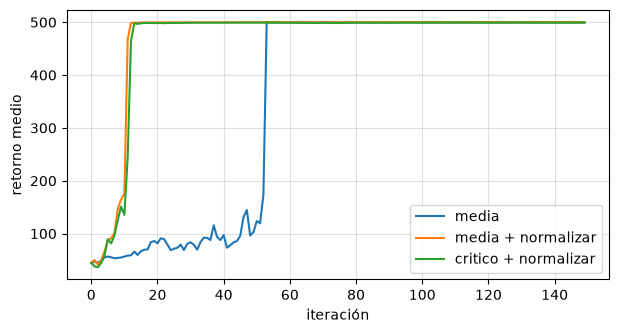

In [7]:
plt.figure(figsize=(7, 3.5))
for (linea_base, normalizar), historial in curvas.items():
    plt.plot(historial, label=f"{linea_base}{' + normalizar' if normalizar else ''}")
plt.xlabel("iteración")
plt.ylabel("retorno medio")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

## 6 · Arma 4: el descuento, de verdad

En el NB29 pusimos γ = 0,99 "porque sí". ¿Qué pasa con otros valores? Recuerda lo que hace γ: cuánto le importa a cada acción lo que pasa **lejos** en el futuro. Con γ = 0,9, una recompensa
a 50 pasos de distancia cuenta 0,9⁵⁰ ≈ 0,005 (casi nada); con γ = 0,99, cuenta 0,99⁵⁰ ≈ 0,6. Probemos la mejor configuración (crítico + normalizar) con varios γ, con 3 semillas cada uno:


In [8]:
print("Peso de una recompensa a 50 pasos:", {g: round(g ** 50, 3) for g in [0.9, 0.95, 0.99, 1.0]})
for gamma in [0.9, 0.95, 0.99, 1.0]:
    llegadas = [primera_por_encima(entrenar("critico", True, 0.3, semilla=s, gamma=gamma)[1]) for s in range(3)]
    print(f"γ = {gamma}: supera 490 en las iteraciones {llegadas}")

Peso de una recompensa a 50 pasos: {0.9: 0.005, 0.95: 0.077, 0.99: 0.605, 1.0: 1.0}


γ = 0.9: supera 490 en las iteraciones [None, None, None]


γ = 0.95: supera 490 en las iteraciones [None, 20, None]


γ = 0.99: supera 490 en las iteraciones [13, 17, 17]


γ = 1.0: supera 490 en las iteraciones [33, 20, 21]


Un resultado muy instructivo:

- Con **γ = 0,9**, **no aprende** (ninguna semilla llega). ¿Por qué? Porque una caída del palo tarda en fraguarse: un mal empujón ahora provoca la caída **decenas** de pasos después. Con
  γ = 0,9, una acción apenas "ve" lo que pasa a más de 10 o 20 pasos, así que **no se entera** de que causó la caída. Es un robot **miope**: solo ve lo inmediato.
- Con **γ = 0,95**, va un poco mejor, pero aún le cuesta.
- Con **γ = 0,99**, aprende bien: ve lo bastante lejos.
- Con **γ = 1** (sin descuento), también aprende, pero algo más despacio: ahora cada acción carga con **todo** lo que pasa hasta el final del episodio, incluidas cosas lejanísimas en las que no
  influyó, y eso añade ruido.

**γ define el "horizonte" del robot**: más o menos, cuántos pasos hacia el futuro le importan (unos 1/(1 − γ) pasos, la serie geométrica del NB28b; con 0,99, unos 100 pasos, 2 segundos en el palo). Tiene
que ser lo bastante largo para **ver las consecuencias de sus actos**, pero no tanto que se llene de ruido. Para un humanoide que anda, donde un mal paso se paga un segundo después, también se
usan valores en torno a 0,99.


## 7 · Hacia dónde vamos: actor-crítico y PPO

Recapitulemos lo que tenemos ya:

- Un **actor** (la política) que explora y se mejora con el gradiente de la política (NB29).
- Un **crítico** (la función de valor) que aprende cuánto vale cada situación, y sirve para calcular la **ventaja** de cada acción en su contexto.
- **Normalización** y un buen **descuento** para domar el ruido.

Esto ya es, casi, un algoritmo **actor-crítico** moderno. Le faltan tres cosas, que veremos en las próximas lecciones:

1. **Redes neuronales** (NB19) en vez de neuronas sueltas, para el actor y para el crítico, entrenadas con **retropropagación automática** (eso es **PyTorch**, que ya hemos instalado en el
   ordenador: el próximo notebook).
2. Un crítico que se usa **paso a paso**, sin esperar a que acabe el episodio (estimando el futuro con el propio crítico: "lo que me dieron ahora + lo que el crítico dice que vale donde he
   llegado"). Así se aprende de episodios largos, o incluso infinitos, como andar.
3. Un **freno** para los pasos de aprendizaje demasiado grandes, y la posibilidad de **reutilizar** cada lote de episodios varias veces. Eso es **PPO** (*Proximal Policy Optimization*), el
   algoritmo con el que se entrenan hoy la mayoría de los humanoides.


## 8 · Resumen de la lección

1. El enemigo del RL es el **ruido** (varianza) de la estimación del gradiente. Se **mide** repitiendo la estimación muchas veces: sin línea base, la dispersión era unas 2-4 veces mayor, y ni
   la dirección media era fiable con 2.000 episodios.
2. **Normalizar las ventajas** (media 0, desviación 1 en cada lote) hace que el tamaño de los pasos no dependa de la escala de los retornos.
3. El **crítico** aprende la **función de valor** V(s), el retorno esperado desde cada situación (aprendizaje supervisado sobre los G). Con **rasgos** (inclinación², velocidad²,
   inclinación × velocidad, momento del episodio) y **mínimos cuadrados** (`np.linalg.lstsq`). Un crítico lineal es un juez **tosco**: fuera de sus datos predice disparates (¡valores negativos!). La **ventaja** = G − V(s) compara cada acción con lo normal **en su situación**. Actor + crítico =
   **actor-crítico**.
4. **Crítico + normalizar** fue lo más rápido y regular (la mayoría de semillas, en menos de 30 iteraciones, frente a 50-95 con la línea base media).
5. El **descuento γ** fija el horizonte (≈ 1/(1 − γ) pasos): con 0,9 el robot es **miope** y no aprende; con 0,99, bien; con 1, algo más ruidoso.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Varianza (del gradiente)** | Cuánto se dispersan las estimaciones de "hacia dónde mejorar". |
| **Normalizar ventajas** | Dejarlas con media 0 y desviación 1 en cada lote. |
| **Función de valor, V(s)** | El retorno esperado desde una situación. |
| **Crítico / actor** | La pieza que juzga situaciones (V) / la que decide acciones (la política). |
| **Actor-crítico** | Arquitectura con un actor que aprende usando las ventajas que calcula un crítico. |
| **Rasgos (*features*)** | Datos fabricados a partir de la observación para alimentar una neurona. |
| **Mínimos cuadrados (`lstsq`)** | Encontrar de golpe los pesos de una neurona lineal que minimizan el error cuadrático. |
| **Horizonte** | Cuántos pasos hacia el futuro le importan al robot (≈ 1/(1 − γ)). |
| **Miope** | Un robot (γ pequeño) que solo ve las consecuencias inmediatas. |
| **PPO** | *Proximal Policy Optimization*: el algoritmo actor-crítico más usado en robótica (llegará). |


## 9 · Ejercicios

**E1.** ¿Por qué el crítico usa la inclinación **al cuadrado** y no la inclinación tal cual?

**E2.** Calcula el horizonte aproximado (1/(1 − γ)) para γ = 0,9, 0,99 y 0,999. ¿Cuántos segundos son en el palo de escoba (cada paso, 0,02 s)?

**E3.** Pregúntale al crítico (la función `valor`) por el palo inclinado 5 grados pero **volviendo** hacia el centro a 20 grados por segundo (velocidad −20), al principio del episodio. ¿Vale más o
menos que inclinado 5 y cayendo (velocidad +20)? ¿Por qué?

**E4.** Repite la medición del ruido del apartado 2 pero usando el **crítico** como línea base. ¿Reduce la dispersión respecto a la media por paso? (Pista: copia `estimar_muchas_veces` y cambia
la línea de las ventajas por `G - rasgos(obs) @ ajustar_critico(obs, G, vivo)`.)

**E5.** Quita el rasgo del **momento** del crítico (deja solo 4 rasgos) y entrena con crítico + normalizar. ¿Empeora?

**E6.** **Reto.** ¿Por qué crees que el crítico tiene que volver a ajustarse en **cada** iteración, y no se ajusta una vez al principio y ya está?


<details>
<summary>▶ Solución E1</summary>

Porque lo que importa para el valor es **cuánto** está inclinado el palo, no hacia qué lado: inclinado 10 grados a la derecha o a la izquierda es igual de peligroso. Con la inclinación tal cual,
una neurona lineal daría valores **opuestos** para +10 y −10 (si uno sale bueno, el otro sale malo), y no podría captar que los dos son igual de malos. Con el **cuadrado**, +10 y −10 dan lo
mismo (100). El cuadrado "se come el signo" (NB04).
</details>

<details>
<summary>▶ Solución E2</summary>

- γ = 0,9 → 1/0,1 = **10 pasos** → 0,2 segundos.
- γ = 0,99 → 1/0,01 = **100 pasos** → 2 segundos.
- γ = 0,999 → 1/0,001 = **1.000 pasos** → 20 segundos (¡más largo que el propio episodio de 10 segundos!).

Con 0,9, el robot solo "ve" dos décimas de segundo hacia delante: demasiado poco para notar que un empujón provocará una caída un segundo después.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
print(valor(5, -20, 0), valor(5, 20, 0))
```

Lo lógico sería que "inclinado 5 pero **volviendo**" valiera **más** que "inclinado 5 y **cayendo**" (es el problema de la foto del NB03). Pero si lo ejecutas, verás que este crítico dice **lo
contrario**: le da más valor a "cayendo". Es un error del crítico, y tiene explicación: el peso del rasgo inclinación × velocidad le salió **positivo** (apartado 4), así que premia que la
inclinación y la velocidad tengan el mismo signo, es decir, caer. Con rasgos relacionados entre sí y datos de una sola política, una neurona lineal puede aprender relaciones absurdas que, en
los datos que vio, "casualmente" ayudaban a predecir.

La lección: **no te fíes de un modelo solo porque su error medio sea bajo; pregúntale por casos concretos y comprueba que tiene sentido**. Este es un ejemplo perfecto de por qué los críticos de
verdad son redes neuronales, y de por qué los ingenieros "interrogan" a sus modelos antes de confiar en ellos.
</details>

<details>
<summary>▶ Solución E4</summary>

```python
def estimar_con_critico(repeticiones=40):
    generador = np.random.default_rng(7)
    estimaciones = []
    for r in range(repeticiones):
        obs, acc, med, rec, vivo = jugar(pesos_fijos, 5.0, 50, generador)
        G = retornos_desde_cada_paso(rec)
        ventajas = G - rasgos(obs) @ ajustar_critico(obs, G, vivo)
        estimaciones.append(direccion_de_mejora(obs, acc, med, ventajas, vivo, 5.0))
    return np.array(estimaciones)

e = estimar_con_critico()
print(e.mean(axis=0).round(1), e.std(axis=0).round(1))
```

Con estos pesos fijos y este crítico tan sencillo, la dispersión sale **parecida** a la de la media por paso, incluso un poco **mayor** (del orden de 10 y 25, frente a 9,5 y 20). ¿Entonces por qué el crítico aprendía más rápido en el apartado 5?
Porque allí iba **junto con normalizar**, y porque un crítico mejora a medida que la política mejora y los episodios se alargan (con episodios largos y situaciones muy distintas entre sí, juzgar
"en contexto" importa cada vez más). Es una lección de método valiosa: **una idea puede no ayudar en una medición concreta y sí en el conjunto**; por eso hay que medir de varias formas.
</details>

<details>
<summary>▶ Solución E5</summary>

Cambia `rasgos` para que no incluya `momento` (quítalo de la lista de `np.stack`) y vuelve a entrenar con `entrenar("critico", True, 0.3, semilla=s)`. Sin el momento, el crítico no sabe que cerca
del final quedan pocas recompensas, y sus predicciones empeoran en esa parte del episodio: las ventajas de las acciones del final quedan sesgadas. Pruébalo con varias semillas y compara las
iteraciones hasta 490 con las del apartado 5.
</details>

<details>
<summary>▶ Solución E6</summary>

Porque el **valor de una situación depende de la política** que se está usando. Con la política del principio (que no sabe nada), una situación "algo inclinado" vale poquísimo (se caerá enseguida);
con la política ya entrenada, la misma situación vale casi 500 (la sabe corregir). Como la política cambia en cada iteración, el crítico tiene que **seguirle el ritmo**: en los algoritmos
actor-crítico, actor y crítico aprenden **a la vez**, sin parar.
</details>


## 10 · 🛠 Práctica en MuJoCo: el ruido, el crítico y el descuento en el palo de física real

En la práctica del NB29 entrenaste por primera vez en MuJoCo, y te llevaste una sorpresa: allí el REINFORCE **puro** también
aprendía. Te prometí que hoy **mediríamos** por qué. Vamos a usar el palo de escoba de MuJoCo como laboratorio y a llevarle las cuatro
armas de esta lección:

1. **Medir** el ruido de la flecha (sin línea base, con la media por paso, con el crítico)... y descubrir **cuándo** importa.
2. El **crítico** de mínimos cuadrados, con los mismos rasgos, ahora juzgando situaciones de física real.
3. **Normalizar** y entrenar con el crítico.
4. El **descuento**, y una idea nueva: el horizonte se mide en **segundos**, y depende del paso de tiempo del simulador.

Todo con las funciones de esta lección **sin cambiar una línea** (`retornos_desde_cada_paso`, `direccion_de_mejora`, `rasgos`,
`ajustar_critico`) y con el `jugar_mujoco` que guardaste en el NB29.


### Paso 1 · Traer el palo de MuJoCo

`jugar_mujoco` está en el fichero `practica_mujoco/nb29_palo_mujoco.py` (NB29, paso 6). Recuerda que no recibe pesos, sino una
**función** que convierte observaciones en medias; para nuestra neurona de dos ruedecillas, `lambda o: o @ pesos` (NB19). Episodios de
3 segundos (300 pasos de 0,01 s), observación [ángulo, giro] en radianes, acción del motor entre −1 y 1, σ = 0,3: lo mismo que en el NB29.


In [9]:
from practica_mujoco.nb29_palo_mujoco import jugar_mujoco

SIGMA_MJ = 0.3
obs, acc, med, rec, vivo = jugar_mujoco(lambda o: o @ np.zeros(2), SIGMA_MJ, 50, np.random.default_rng(0))
print("Forma de las observaciones:", obs.shape, "| retorno medio sin saber nada:", round((rec * vivo).sum(axis=0).mean(), 1))

Forma de las observaciones: (300, 50, 2) | retorno medio sin saber nada: 70.2


(300 pasos, 50 episodios, 2 números por observación. Y los ~70 puntos del NB29: sin saber nada, el palo dura menos de un segundo.)

### Paso 2 · Medir el ruido, en dos momentos del aprendizaje

Hacemos lo del apartado 2: estimar la flecha **20 veces** con los mismos pesos (cada vez con un lote nuevo de 50 episodios) y mirar su
dispersión. Pero ahora en **dos momentos**:

- **Al principio** del aprendizaje: pesos (0, 0), la política que no sabe nada.
- **Al final**: pesos (2,2; 0,35), más o menos los que aprendió el NB29, una política que ya sostiene el palo.

Y con las tres formas de calcular las ventajas: sin línea base, con la media por paso y con el crítico. (Tarda unos 20 segundos.)


In [10]:
def ventajas_segun(modo, obs, G, vivo):
    if modo == "sin línea base":
        return G
    if modo == "media por paso":
        return G - G.mean(axis=1, keepdims=True)
    return G - rasgos(obs) @ ajustar_critico(obs, G, vivo)          # "crítico"

for nombre, pesos_mj in [("al principio", np.array([0.0, 0.0])), ("al final", np.array([2.2, 0.35]))]:
    print(f"--- {nombre}, pesos {pesos_mj} ---")
    for modo in ["sin línea base", "media por paso", "crítico"]:
        generador = np.random.default_rng(7)
        flechas = []
        for r in range(20):
            obs, acc, med, rec, vivo = jugar_mujoco(lambda o: o @ pesos_mj, SIGMA_MJ, 50, generador)
            G = retornos_desde_cada_paso(rec)
            flechas.append(direccion_de_mejora(obs, acc, med, ventajas_segun(modo, obs, G, vivo), vivo, SIGMA_MJ))
        flechas = np.array(flechas)
        print(f"{modo:>15}: media {flechas.mean(axis=0).round(1)} | dispersión {flechas.std(axis=0).round(1)}"
              f" | flechas con el primer número negativo: {(flechas[:, 0] < 0).sum()} de 20")

--- al principio, pesos [0. 0.] ---


 sin línea base: media [14.7 39.7] | dispersión [ 8.1 31.3] | flechas con el primer número negativo: 1 de 20


 media por paso: media [14.7 46.9] | dispersión [ 8.  32.9] | flechas con el primer número negativo: 0 de 20


        crítico: media [13.8 43.3] | dispersión [ 7.5 34.2] | flechas con el primer número negativo: 0 de 20
--- al final, pesos [2.2  0.35] ---


 sin línea base: media [  2.5 -17.2] | dispersión [26.  64.4] | flechas con el primer número negativo: 11 de 20


 media por paso: media [5.  0.9] | dispersión [ 5.1 28.7] | flechas con el primer número negativo: 3 de 20


        crítico: media [ 4.7 -8.6] | dispersión [ 3.9 24.1] | flechas con el primer número negativo: 2 de 20


Aquí está la respuesta a la sorpresa del NB29. Lee las dos mitades de la salida por separado:

- **Al principio**, las tres formas dan casi **la misma** dispersión (unos 8 en la primera ruedecilla, unos 31-34 en la segunda), y la
  media de la flecha es claramente **positiva**: "empuja hacia donde cae el palo". La señal es tan fuerte que el ruido apenas importa.
  Por eso el REINFORCE puro aprendía.
- **Al final**, todo cambia. Sin línea base, la dispersión de la primera ruedecilla sube a unos **26**, y la media se queda en unos 2,5:
  el ruido es **diez veces** mayor que la señal, y **11 de las 20** flechas apuntan hacia el lado contrario. Con la media por paso, la
  dispersión baja a unos **5**; con el crítico, a unos **4**: entre cinco y siete veces menos ruido.

¿Por qué? Cuando la política ya es buena, casi todos los episodios duran los 300 pasos y sus retornos son **altos y parecidos**. Sin línea
base, **todas** las acciones reciben un refuerzo grande y positivo (el problema de las golosinas del NB29), y la poca información útil
("esta acción fue un poco mejor que aquella") queda enterrada. La línea base resta esa parte común y deja a la vista las diferencias.

**Lección:** las armas contra el ruido importan sobre todo **al afinar**, cuando la política ya es buena y lo que queda por aprender es
sutil. Para un humanoide, que pasa casi todo su entrenamiento afinando, son imprescindibles.


### Paso 3 · Interrogar al crítico de MuJoCo

El crítico es el mismo del apartado 4: rasgos [1, ángulo², giro², ángulo × giro, momento] y mínimos cuadrados. Lo ajustamos con un lote de
la política buena y le preguntamos, como hicimos con el palo de juguete, por tres situaciones. Ojo con las unidades: ahora el ángulo va en
**radianes** (`np.radians`) y el momento es el paso dividido entre **300** (lo que duran estos episodios):


In [11]:
obs, acc, med, rec, vivo = jugar_mujoco(lambda o: o @ np.array([2.2, 0.35]), SIGMA_MJ, 50, np.random.default_rng(3))
G = retornos_desde_cada_paso(rec)
pesos_criticos_mj = ajustar_critico(obs, G, vivo)

def valor_mj(grados, grados_por_segundo, paso):
    i, v = np.radians(grados), np.radians(grados_por_segundo)
    return np.array([1.0, i ** 2, v ** 2, i * v, paso / 300]) @ pesos_criticos_mj

print(f"Derecho y quieto, al principio:      V = {valor_mj(0, 0, 0):6.1f}")
print(f"Inclinado 3° y cayendo, al principio: V = {valor_mj(3, 20, 0):6.1f}")
print(f"Derecho y quieto, casi al final:     V = {valor_mj(0, 0, 290):6.1f}")

Derecho y quieto, al principio:      V =  109.5
Inclinado 3° y cayendo, al principio: V =  108.8
Derecho y quieto, casi al final:     V =   30.2


Mira los números con lupa, como en el apartado 4. La tercera respuesta tiene sentido: casi al final quedan solo 10 pasos, y el crítico
espera unos **30** puntos (menos que al principio, bien; pero más de los ~10 que de verdad quedan). Las otras dos son **imposibles**: con
γ = 0,99 y 300 pasos, el retorno máximo es 1 + 0,99 + 0,99² + ... ≈ **95**, y el crítico dice unos **110**. Y apenas distingue
"derecho y quieto" de "inclinado y cayendo" (109,5 frente a 108,8).

Es el mismo juez **tosco** de la lección: una neurona lineal con cinco rasgos, ajustada con datos de una política que casi siempre aguanta
los 300 pasos. Para que la media de sus predicciones cuadre, se pasa por arriba al principio y por abajo al final (el rasgo "momento" es
una línea recta, y el retorno de verdad cae como una curva). Aun así, como línea base sirve, porque lo que importa es que se lleve la
parte **común** de los retornos (paso 2). Un crítico que de verdad entienda las situaciones será una **red** (NB32).


### Paso 4 · Entrenar: media por paso contra crítico + normalizar

Ahora, la comparación del apartado 5 en MuJoCo. Usamos la función `entrenar` de la lección como plantilla, cambiando solo el `jugar`. Dos
tasas, medidas probando (NB17): 0,003 para la media por paso (la del NB29) y **0,1** para crítico + normalizar (las ventajas normalizadas
son números de tamaño 1, mucho más pequeños, así que hace falta una tasa mayor). 40 iteraciones de 50 episodios cada una, semilla 0.
Unos 15 segundos:


media por paso:     pesos [2.13 0.72] | últimas 5 iteraciones: 292
crítico+normalizar: pesos [2.58 5.88] | últimas 5 iteraciones: 281


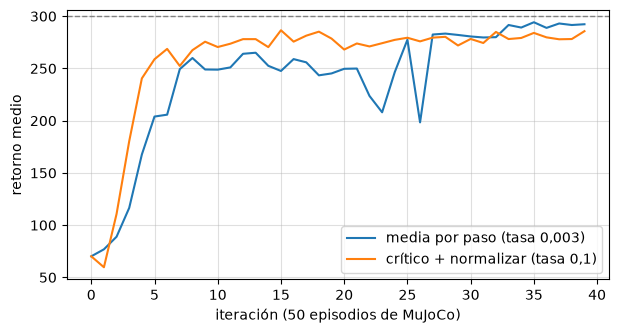

In [12]:
def entrenar_mj(linea_base, normalizar, tasa, gamma=0.99, iteraciones=40, semilla=0, viento=0.0):
    generador = np.random.default_rng(semilla)
    pesos = np.zeros(2)
    historial = []
    for iteracion in range(iteraciones):
        obs, acc, med, rec, vivo = jugar_mujoco(lambda o: o @ pesos, SIGMA_MJ, 50, generador, viento=viento)
        historial.append((rec * vivo).sum(axis=0).mean())
        G = retornos_desde_cada_paso(rec, gamma)
        ventajas = ventajas_segun(linea_base, obs, G, vivo)
        if normalizar:
            ventajas = (ventajas - ventajas[vivo].mean()) / (ventajas[vivo].std() + 1e-8)
        pesos = pesos + tasa * direccion_de_mejora(obs, acc, med, ventajas, vivo, SIGMA_MJ)
    return pesos, historial

pesos_media, h_media = entrenar_mj("media por paso", False, 0.003)
pesos_critico, h_critico = entrenar_mj("crítico", True, 0.1)
print("media por paso:     pesos", pesos_media.round(2), "| últimas 5 iteraciones:", round(np.mean(h_media[-5:])))
print("crítico+normalizar: pesos", pesos_critico.round(2), "| últimas 5 iteraciones:", round(np.mean(h_critico[-5:])))

plt.figure(figsize=(7, 3.5))
plt.plot(h_media, label="media por paso (tasa 0,003)")
plt.plot(h_critico, label="crítico + normalizar (tasa 0,1)")
plt.axhline(300, color="gray", linestyle="--", linewidth=1)
plt.xlabel("iteración (50 episodios de MuJoCo)")
plt.ylabel("retorno medio")
plt.legend()
plt.grid(True, alpha=0.4)
plt.show()

Las dos aprenden y acaban por encima de **280** (de unos 300 posibles), en un número de iteraciones parecido. Aquí el crítico **no** saca la
ventaja que sacaba en el palo de juguete, y ya sabes por qué (paso 2): en este palo sin viento, la parte difícil del aprendizaje es
corta, la señal es fuerte y casi cualquier línea base sirve. Y fíjate en los pesos: con el crítico salen **más grandes** (normalizar
hace que los pasos no se encojan cuando las ventajas son pequeñas). Hay muchas ruedecillas que funcionan (NB29).

Contarlo así, sin adornarlo, es parte del oficio: **una técnica que acelera mucho un problema puede no cambiar nada en otro**. Por eso se mide.


### Paso 5 · El descuento, en segundos

En el apartado 6, con el palo de juguete, γ = 0,9 **no aprendía**: el robot era miope. Probémoslo en MuJoCo (crítico + normalizar, unos 15
segundos):


In [13]:
for gamma in [0.9, 0.99]:
    pesos_g, h_g = entrenar_mj("crítico", True, 0.1, gamma=gamma)
    print(f"γ = {gamma}: horizonte ≈ {1 / (1 - gamma):.0f} pasos = {0.01 / (1 - gamma):.1f} s"
          f" | últimas 5 iteraciones: {np.mean(h_g[-5:]):.0f}")

γ = 0.9: horizonte ≈ 10 pasos = 0.1 s | últimas 5 iteraciones: 283


γ = 0.99: horizonte ≈ 100 pasos = 1.0 s | últimas 5 iteraciones: 281


¡Aquí γ = 0,9 **sí** aprende! ¿Contradice el apartado 6? No, y la razón es muy de simulador: **el horizonte se mide en pasos, pero
la física ocurre en segundos**. Un horizonte de 1/(1 − γ) pasos dura:

```
   horizonte en segundos  ≈  paso de tiempo / (1 − γ)
```

El palo de juguete daba pasos de 0,02 s y caía despacio (con el viento, una mala acción se pagaba un segundo después); este palo de MuJoCo
va a 0,01 s y, sin motor, **cae en 0,58 s** desde 5° (NB28). Con γ = 0,9 ve 0,1 s por delante: poco, pero, para un palo que cae tan
deprisa, una mala acción ya se nota en el siguiente puñado de pasos.

Consecuencia práctica, que verás en todos los entornos de robots: **si cambias el paso de tiempo del simulador, tienes que cambiar γ**. Si
pasas de 0,01 s a 0,002 s (cinco veces más pasos por segundo), con el mismo γ el robot verá cinco veces menos tiempo hacia delante.


### Tus retos

**R1.** Repite el paso 4 con **viento** (`viento=5.0`, ráfagas de hasta 5 newtons sobre el palo) y las semillas 0, 1 y 2. ¿Ayuda el crítico
cuando el mundo es más ruidoso?

**R2.** En el NB29 viste que la política que solo mira el palo deja que el carro derive y, pasados unos 3 segundos, choca con el tope.
¿Qué γ haría falta para que el horizonte fuera de **3 segundos** en este palo de MuJoCo (paso de 0,01 s)? ¿Y en el humanoide de
Gymnasium, que da pasos de 0,015 s?

**R3.** **Reto.** Con los pesos del final (2,2; 0,35), mide el ruido de la flecha sin línea base y con el crítico usando **lotes de 200
episodios** en vez de 50 (10 repeticiones). ¿Cuánto baja la dispersión? ¿Compensa jugar 4 veces más?


<details>
<summary>▶ Solución R1</summary>

```python
for linea_base, normalizar, tasa in [("media por paso", False, 0.003), ("crítico", True, 0.1)]:
    finales = [round(np.mean(entrenar_mj(linea_base, normalizar, tasa, semilla=s, viento=5.0)[1][-5:])) for s in range(3)]
    print(linea_base, finales)
```

Medido (unos 45 segundos): con la media por paso, **254, 240 y 254**; con crítico + normalizar, **245, 219 y 258**. Con viento, los dos
aprenden peor que sin él (el viento es ruido en el mundo y además hace el palo más difícil), y el crítico **no** gana: su línea base lineal
de cinco rasgos es tosca, y con tasa 0,1 da pasos más grandes y más irregulares. Para que un crítico marque la diferencia hace falta que
**juzgue bien**: una red neuronal, como verás en el NB32.
</details>

<details>
<summary>▶ Solución R2</summary>

Horizonte en pasos = 3 s / 0,01 s = 300 pasos, y 1/(1 − γ) = 300 → γ = 1 − 1/300 ≈ **0,9967**.

En el humanoide, 3 s / 0,015 s = 200 pasos → γ = 1 − 1/200 = **0,995**. (Los entrenamientos de humanoides usan, de hecho, valores entre
0,99 y 0,995.) Y ojo: un horizonte largo no basta. Con la observación del NB29, el robot **no ve el carro**, así que aunque le importe el
futuro, no puede saber que va derivando (NB29, R4). Lo arreglaremos en el NB32.
</details>

<details>
<summary>▶ Solución R3</summary>

```python
for modo in ["sin línea base", "crítico"]:
    generador = np.random.default_rng(7)
    flechas = []
    for r in range(10):
        obs, acc, med, rec, vivo = jugar_mujoco(lambda o: o @ np.array([2.2, 0.35]), SIGMA_MJ, 200, generador)
        G = retornos_desde_cada_paso(rec)
        flechas.append(direccion_de_mejora(obs, acc, med, ventajas_segun(modo, obs, G, vivo), vivo, SIGMA_MJ))
    print(modo, np.array(flechas).std(axis=0).round(1))
```

Medido: sin línea base, la dispersión de la primera ruedecilla baja de unos 26 a unos **12**; con el crítico, de unos 4 a unos **1,8**.
Cuatro veces más episodios dividen el ruido entre **dos**, no entre cuatro: es la raíz cuadrada del error típico (NB28, √4 = 2). Y fíjate
en la comparación que importa: el crítico con 50 episodios (≈ 4) es **tres veces** más preciso que no usar línea base con 200 (≈ 12), y
sin línea base, aun con 200 episodios, la mitad de las flechas (5 de 10) siguen apuntando al revés. **Jugar más es caro y ayuda poco;
una buena línea base es gratis y ayuda mucho.** Esa es la razón de ser de los críticos.
</details>


### Qué has aprendido de MuJoCo hoy

- El ruido de la flecha se **mide** en MuJoCo igual que en cualquier otro mundo: repetir la estimación con los mismos pesos y mirar su dispersión.
- En el palo de MuJoCo, la línea base casi no importa **al principio** (señal fuerte) y es **imprescindible al final** (sin ella, la mitad
  de las flechas apuntan al revés).
- Las piezas de RL (crítico de mínimos cuadrados, normalizar) se enchufan a MuJoCo **sin cambiar una línea**; solo cambian las **unidades**
  (radianes) y las **tasas**.
- El horizonte del descuento se mide en **segundos**: paso de tiempo / (1 − γ). Si cambias `opt.timestep`, revisa γ.
- Una técnica que ayuda mucho en un problema puede no cambiar nada en otro: **se mide**.

En la práctica del **NB31** la política dejará de ser una neurona de NumPy: será una **red de PyTorch** que controla el palo de MuJoCo, con
las pendientes calculadas por autograd.


## 11 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Hoy has aprendido a medir y domar el ruido, has construido tu primer **crítico**, y has visto que el descuento define lo lejos que "ve" un robot (y, en la práctica en MuJoCo, que ese "lejos" se mide en segundos y que la línea base importa sobre todo al afinar). En el **NB31** llega la herramienta que usa toda la
industria para construir y entrenar redes neuronales: **PyTorch**. Verás que hace **sola** la retropropagación que escribiste a mano en el NB19 (se llama **autograd**), y rehicimos en unas pocas
líneas lo que nos costó una lección entera. Con PyTorch, el actor y el crítico podrán ser **redes neuronales** de verdad.
